## Análise de Dados para detecção e classificação de doenças em sementes de Soja

In [24]:
import pandas as pd
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras import Input
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer

### Dicionário de Dados

date: mês da observação (ex: july, october)

plant-stand: condição das plantas (ex: normal)

precip: precipitação (ex: gt-norm = greater than normal)

temp: temperatura (ex: norm)

hail: ocorrência de granizo (ex: yes, no)

crop-hist: histórico da lavoura (ex: same-lst-yr)

area-damaged: área danificada (ex: scattered, low-areas)

severity: severidade do dano (ex: severe, pot-severe)

seed-tmt: tratamento das sementes (ex: fungicide, none)

germination: taxa de germinação (ex: lt-80, 80-89, 90-100)

fruit-pods, fruit-spots, seed, mold-growth, roots: características visuais das plantas

class: variável alvo, indicando a doença (ex: diaporthe-stem-canker)

In [2]:
df = pd.read_csv('soybean.csv')
df.head()

,date,plant-stand,precip,temp,hail,crop-hist,area-damaged,severity,seed-tmt,germination,...,sclerotia,fruit-pods,fruit-spots,seed,mold-growth,seed-discolor,seed-size,shriveling,roots,class
0,october,normal,gt-norm,norm,yes,same-lst-yr,low-areas,pot-severe,none,90-100,...,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker
1,august,normal,gt-norm,norm,yes,same-lst-two-yrs,scattered,severe,fungicide,80-89,...,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker
2,july,normal,gt-norm,norm,yes,same-lst-yr,scattered,severe,fungicide,lt-80,...,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker
3,july,normal,gt-norm,norm,yes,same-lst-yr,scattered,severe,none,80-89,...,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker
4,october,normal,gt-norm,norm,yes,same-lst-two-yrs,scattered,pot-severe,none,lt-80,...,absent,norm,dna,norm,absent,absent,norm,absent,norm,diaporthe-stem-canker


In [3]:
df.shape

(683, 36)

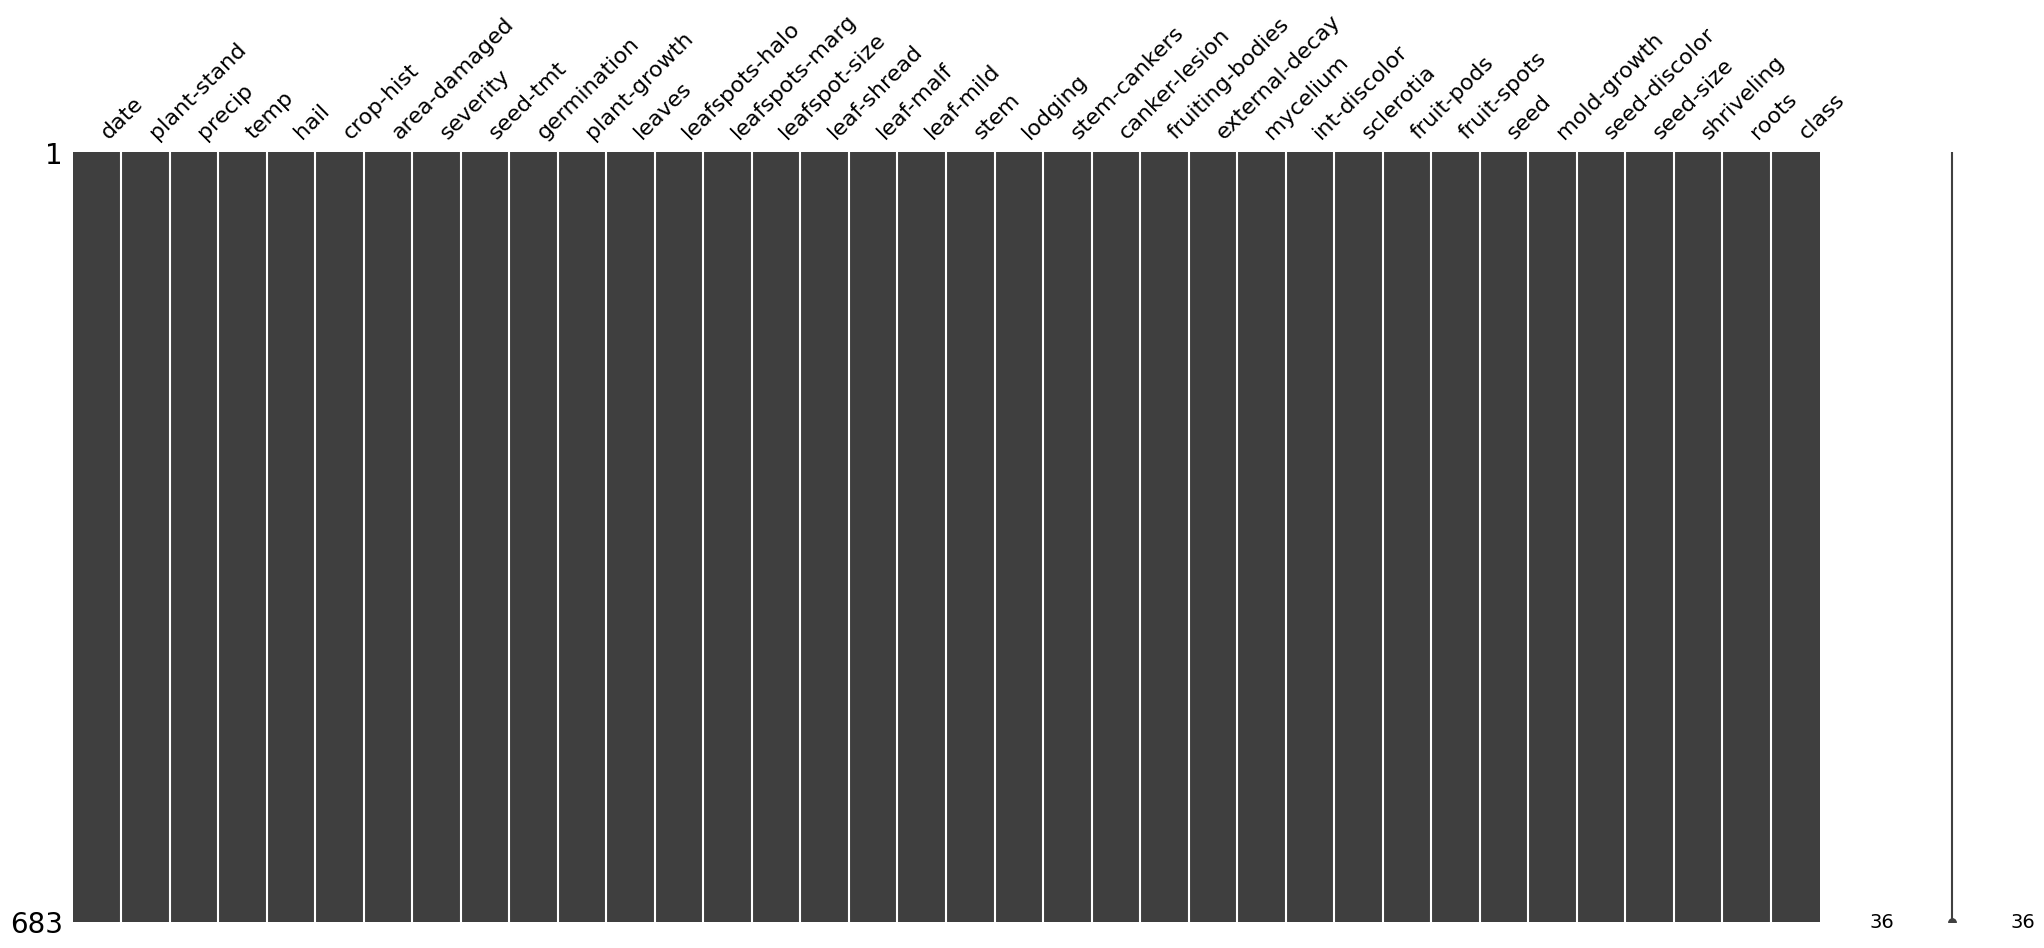

In [4]:
import missingno as msno
ax = msno.matrix(df.sample(683))

### Apesar de não haver dados Nulos existem colunas com '?' e isso pode gerar uma falsa noção de correlação entre os dados

In [5]:
df.iloc[:,9:27]

,germination,plant-growth,leaves,leafspots-halo,leafspots-marg,leafspot-size,leaf-shread,leaf-malf,leaf-mild,stem,lodging,stem-cankers,canker-lesion,fruiting-bodies,external-decay,mycelium,int-discolor,sclerotia
0,90-100,abnorm,abnorm,absent,dna,dna,absent,absent,absent,abnorm,no,above-sec-nde,brown,present,firm-and-dry,absent,none,absent
1,80-89,abnorm,abnorm,absent,dna,dna,absent,absent,absent,abnorm,yes,above-sec-nde,brown,present,firm-and-dry,absent,none,absent
2,lt-80,abnorm,abnorm,absent,dna,dna,absent,absent,absent,abnorm,yes,above-sec-nde,dna,present,firm-and-dry,absent,none,absent
3,80-89,abnorm,abnorm,absent,dna,dna,absent,absent,absent,abnorm,yes,above-sec-nde,dna,present,firm-and-dry,absent,none,absent
4,lt-80,abnorm,abnorm,absent,dna,dna,absent,absent,absent,abnorm,yes,above-sec-nde,brown,present,firm-and-dry,absent,none,absent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678,?,?,abnorm,absent,dna,dna,?,present,?,?,?,?,?,?,?,?,?,?
679,?,abnorm,abnorm,absent,dna,dna,absent,present,?,abnorm,?,?,?,?,?,?,?,?
680,?,abnorm,abnorm,absent,dna,dna,absent,present,?,abnorm,?,?,?,?,?,?,?,?
681,?,abnorm,abnorm,no-yellow-halos,no-w-s-marg,gt-1/8,absent,present,?,abnorm,?,?,?,?,?,?,?,?


In [6]:
# Para cada coluna, contamos quantas vezes aparece '?'
colunas_com_interrogacao = (df == '?').sum()

# Filtra apenas as colunas onde há pelo menos uma ocorrência de '?'
colunas_com_interrogacao = colunas_com_interrogacao[colunas_com_interrogacao > 0]

# Exibe o resultado
print("Colunas com '?' e suas respectivas quantidades:")
print(colunas_com_interrogacao)

Colunas com '?' e suas respectivas quantidades:
date                 1
plant-stand         36
precip              38
temp                30
hail               121
crop-hist           16
area-damaged         1
severity           121
seed-tmt           121
germination        112
plant-growth        16
leafspots-halo      84
leafspots-marg      84
leafspot-size       84
leaf-shread        100
leaf-malf           84
leaf-mild          108
stem                16
lodging            121
stem-cankers        38
canker-lesion       38
fruiting-bodies    106
external-decay      38
mycelium            38
int-discolor        38
sclerotia           38
fruit-pods          84
fruit-spots        106
seed                92
mold-growth         92
seed-discolor      106
seed-size           92
shriveling         106
roots               31
dtype: int64


In [7]:
# Atualização dos valores '?' para null
df.replace('?', np.nan, inplace=True)

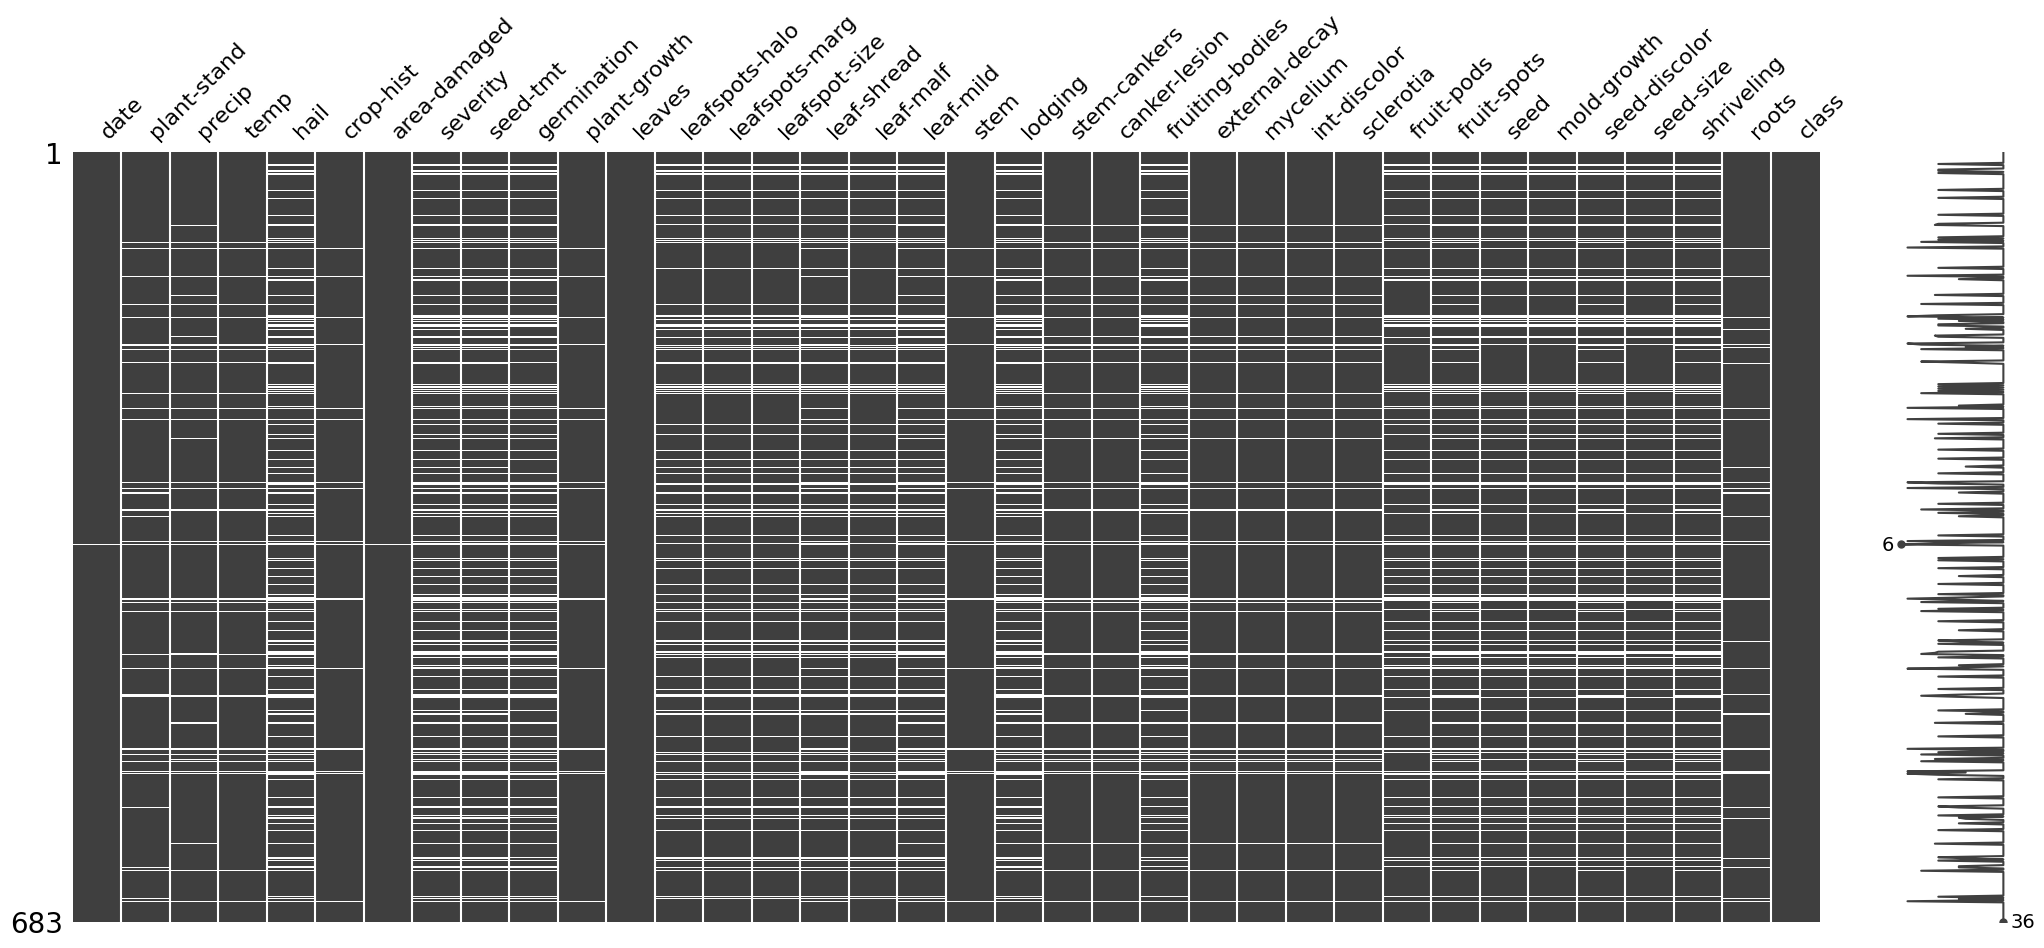

In [8]:
import missingno as msno
ax = msno.matrix(df.sample(683))

### Tratamento de dados ausentes

In [9]:
## Colunas com menos de 5% de casos nulos receberão a moda 

colunas_menos_5 = df.columns[df.isnull().mean() < 0.05]

for col in colunas_menos_5:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
## Demais casos serão tratados com Modelo de ML para imputação dos dados e preservar o contexto
## O KNNImputer analisará a média dos 5 vizihos mais próximos para imputar valores.

from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder

# Codifica variáveis categóricas em valores numéricos (necessário para KNNImputer)
encoder = OrdinalEncoder()
df_encoded = pd.DataFrame(
    encoder.fit_transform(df),
    columns=df.columns
)

# Aplica imputação com KNN
imputer = KNNImputer(n_neighbors=5)
df_imputado = pd.DataFrame(
    imputer.fit_transform(df_encoded),
    columns=df.columns
)

# Arredonda valores se quiser reconverter depois para categoria
df_imputado = df_imputado.round(0)

# Reverter codificação se quiser voltar para rótulos originais
df_final = pd.DataFrame(
    encoder.inverse_transform(df_imputado),
    columns=df.columns
)

In [11]:
df_final.isnull().sum()

date               0
plant-stand        0
precip             0
temp               0
hail               0
crop-hist          0
area-damaged       0
severity           0
seed-tmt           0
germination        0
plant-growth       0
leaves             0
leafspots-halo     0
leafspots-marg     0
leafspot-size      0
leaf-shread        0
leaf-malf          0
leaf-mild          0
stem               0
lodging            0
stem-cankers       0
canker-lesion      0
fruiting-bodies    0
external-decay     0
mycelium           0
int-discolor       0
sclerotia          0
fruit-pods         0
fruit-spots        0
seed               0
mold-growth        0
seed-discolor      0
seed-size          0
shriveling         0
roots              0
class              0
dtype: int64

### Modelagem

In [12]:
X = df_final.iloc[:,:35].values

In [13]:
y = df_final.iloc[:,35].values

In [14]:
encoder = OneHotEncoder(handle_unknown='ignore')
X_encoded = encoder.fit_transform(X)
X_encoded

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 23905 stored elements and shape (683, 99)>

In [15]:
from keras.utils import to_categorical

# y ainda é categórico (ex: ['diaporthe-stem-canker', ...])
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Agora y vai ser algo como [0, 0, 1, 2, ...]

# converte para one-hot (opcional, depende da sua arquitetura)
y_categorical = to_categorical(y_encoded)

In [16]:
y_categorical.shape

(683, 19)

In [17]:
X_encoded_dense = X_encoded.toarray()  # transforma de sparse para numpy array

In [18]:
#separação em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_encoded_dense, y_categorical, test_size = 0.3, random_state = 457)

print(len(X_train),len(X_test),len(y_train),len(y_test))

478 205 478 205


## RNN

In [19]:
classificador = Sequential()
classificador.add(Input(shape=(99,)))
classificador.add(Dense(128, activation='relu'))
classificador.add(Dense(64, activation='relu'))
classificador.add(Dense(19, activation='softmax'))

classificador.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    min_delta=0.001,
    restore_best_weights=True
)

classificador.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=10,
    callbacks=[early_stop]
)

Epoch 1/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1841 - loss: 2.7123 - val_accuracy: 0.5024 - val_loss: 1.8222
Epoch 2/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5932 - loss: 1.5596 - val_accuracy: 0.7561 - val_loss: 0.9603
Epoch 3/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8324 - loss: 0.7430 - val_accuracy: 0.8390 - val_loss: 0.5623
Epoch 4/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9033 - loss: 0.4204 - val_accuracy: 0.8976 - val_loss: 0.3710
Epoch 5/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9221 - loss: 0.3108 - val_accuracy: 0.9024 - val_loss: 0.2947
Epoch 6/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9463 - loss: 0.1909 - val_accuracy: 0.9268 - val_loss: 0.2692
Epoch 7/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9667 - loss: 0.1382 - val_accuracy: 0.9220 - val_loss: 0.2533
Epoch 8/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9716 - loss: 0.1145 - val_accuracy: 0.9317 - 

### Visualização

Epoch 1/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9736 - loss: 0.0585 - val_accuracy: 0.9220 - val_loss: 0.2388
Epoch 2/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9609 - loss: 0.0891 - val_accuracy: 0.9268 - val_loss: 0.2172
Epoch 3/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9871 - loss: 0.0592 - val_accuracy: 0.9220 - val_loss: 0.2388
Epoch 4/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9882 - loss: 0.0428 - val_accuracy: 0.9317 - val_loss: 0.2285
Epoch 5/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9810 - loss: 0.0462 - val_accuracy: 0.9171 - val_loss: 0.2385
Epoch 6/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9820 - loss: 0.0393 - val_accuracy: 0.9220 - val_loss: 0.2459
Epoch 7/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9636 - loss: 0.0638 - val_accuracy: 0.9268 - val_loss: 0.2361
Epoch 8/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9888 - loss: 0.0406 - val_accuracy: 0.9268 -

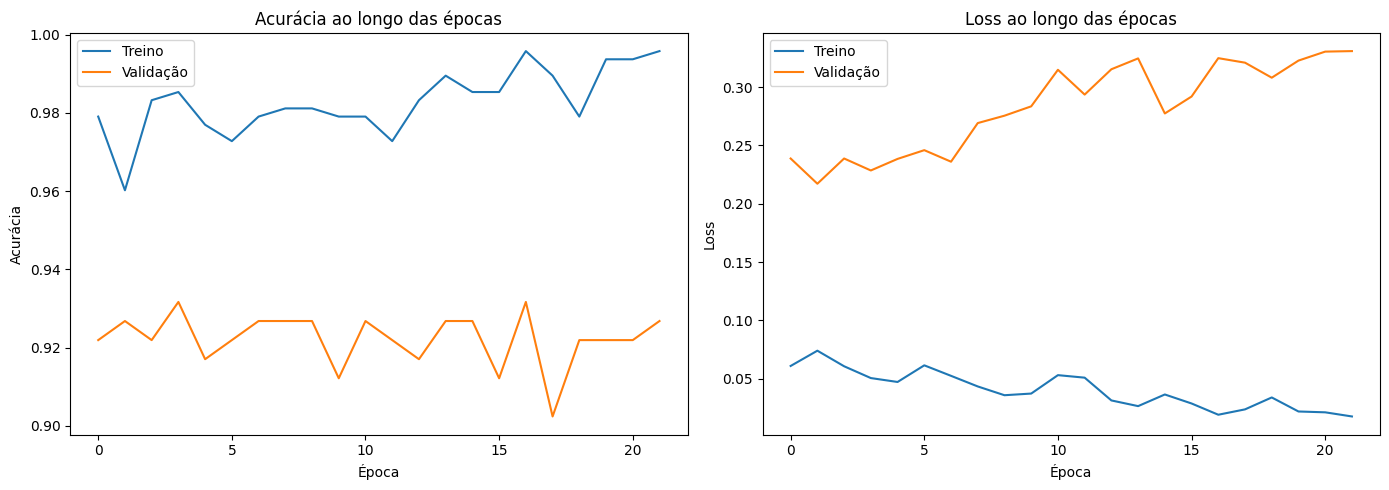

In [20]:
import matplotlib.pyplot as plt

# Supondo que você salvou o histórico do treino assim:
hist = classificador.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=10,
    callbacks=[early_stop]
)

# Plotando a acurácia
plt.figure(figsize=(14,5))

plt.subplot(1, 2, 1)
plt.plot(hist.history['accuracy'], label='Treino')
plt.plot(hist.history['val_accuracy'], label='Validação')
plt.title('Acurácia ao longo das épocas')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

# Plotando o loss
plt.subplot(1, 2, 2)
plt.plot(hist.history['loss'], label='Treino')
plt.plot(hist.history['val_loss'], label='Validação')
plt.title('Loss ao longo das épocas')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Comparação de resultados com RadomForest

In [22]:
# Criação do classificador Random Forest
from sklearn.ensemble import RandomForestClassifier
floresta = RandomForestClassifier(n_estimators = 100)
floresta.fit(X_train, y_train)

RandomForestClassifier()

In [28]:
previsoes = floresta.predict(X_test)
taxa_acerto = accuracy_score(y_test, previsoes)
taxa_acerto = taxa_acerto * 100
print(f'Resultado com RandomForest: {taxa_acerto:.2f} %')

Resultado com RandomForest: 88.29 %


## Identificação dos melhores parâmetros

In [38]:
import optuna

def objective(trial):
    units_1 = trial.suggest_int('units_1', 128, 256, step=32)
    units_2 = trial.suggest_int('units_2', 64, 128, step=32)
    
    optimizer = trial.suggest_categorical('optimizer', ['adam', 'rmsprop'])
    batch_size = trial.suggest_categorical('batch_size', [10, 20])
    epochs = trial.suggest_int('epochs', 50, 150)

    model = Sequential()
    model.add(Input(shape=(99,)))
    model.add(Dense(units_1, activation='relu'))
    model.add(Dense(units_2, activation='relu'))
    model.add(Dense(19, activation='softmax'))
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(X_train, y_train,
                        validation_data=(X_test, y_test),
                        epochs=epochs,
                        batch_size=batch_size,
                        verbose=0)

    return max(history.history['val_accuracy'])

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print("Melhores parâmetros:", study.best_params)

[I 2025-06-22 17:01:26,438] A new study created in memory with name: no-name-e8e33800-c6a5-437a-8dc1-8db1e4d2c7ab
[I 2025-06-22 17:01:57,245] Trial 0 finished with value: 0.9365853667259216 and parameters: {'units_1': 128, 'units_2': 64, 'optimizer': 'rmsprop', 'batch_size': 10, 'epochs': 79}. Best is trial 0 with value: 0.9365853667259216.
[I 2025-06-22 17:02:27,635] Trial 1 finished with value: 0.9317073225975037 and parameters: {'units_1': 128, 'units_2': 96, 'optimizer': 'rmsprop', 'batch_size': 10, 'epochs': 91}. Best is trial 0 with value: 0.9365853667259216.
[I 2025-06-22 17:03:17,059] Trial 2 finished with value: 0.9365853667259216 and parameters: {'units_1': 192, 'units_2': 96, 'optimizer': 'rmsprop', 'batch_size': 10, 'epochs': 147}. Best is trial 0 with value: 0.9365853667259216.
[I 2025-06-22 17:03:48,865] Trial 3 finished with value: 0.9414634108543396 and parameters: {'units_1': 256, 'units_2': 64, 'optimizer': 'adam', 'batch_size': 10, 'epochs': 92}. Best is trial 3 with

Melhores parâmetros: {'units_1': 256, 'units_2': 64, 'optimizer': 'adam', 'batch_size': 10, 'epochs': 92}


## Validação Cruzada e apresentação de resultados

In [39]:
# Aplicação do melhor modelo com validação cruzada

from sklearn.model_selection import KFold
import numpy as np

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_ix, val_ix in kfold.split(X_encoded_dense):
    model = Sequential()
    model.add(Input(shape=(99,)))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(19, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Split
    X_train, X_val = X_encoded_dense[train_ix], X_encoded_dense[val_ix]
    y_train, y_val = y_categorical[train_ix], y_categorical[val_ix]

    history = model.fit(X_train, y_train, epochs=92, batch_size=10, verbose=0)
    _, acc = model.evaluate(X_val, y_val, verbose=0)
    scores.append(acc)

# Resultados
media = np.mean(scores)
desvio = np.std(scores)
dois_desvios = desvio * 2

print(f"Acurácia média: {media:.4f}")
print(f"Desvio padrão: {desvio:.4f}")
print(f"Intervalo: [{media - dois_desvios:.4f}, {media + dois_desvios:.4f}]")

Acurácia média: 0.9253
Desvio padrão: 0.0125
Intervalo: [0.9003, 0.9504]


In [43]:
print("Após testar com diferentes grupos do conjunto de dados obtemos uma média de 92% de acurácia")
print("E um intervalo de previsão entre 90% e 95% de acurácia com 95% de confiança")

Após testar com diferentes grupos do conjunto de dados obtemos uma média de 92% de acurácia
E um intervalo de previsão entre 90% e 95% de acurácia com 95% de confiança


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


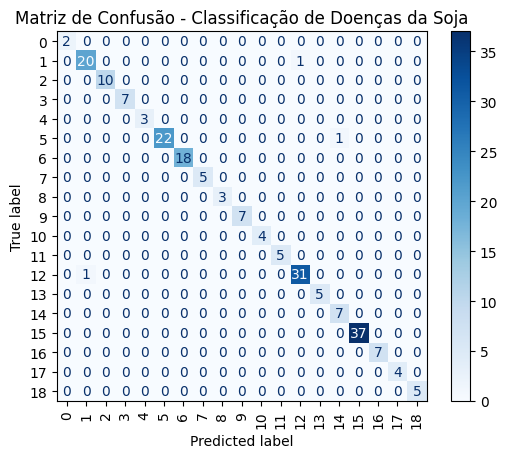

In [47]:
# Matriz de confusão

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Obter as classes reais e previstas
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

# Gerar a matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# Exibir a matriz de confusão com rótulos
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=90)
plt.title("Matriz de Confusão - Classificação de Doenças da Soja")
plt.show()
